In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import ast
import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv(r"C:\Users\ninja\Downloads\job_descriptions.csv")


print(" Shape:", df.shape)
print("\n Columns:", df.columns.tolist())
print("\n First 3 rows:")
print(df.head(3))

 Shape: (1615940, 23)

 Columns: ['Job Id', 'Experience', 'Qualifications', 'Salary Range', 'location', 'Country', 'latitude', 'longitude', 'Work Type', 'Company Size', 'Job Posting Date', 'Preference', 'Contact Person', 'Contact', 'Job Title', 'Role', 'Job Portal', 'Job Description', 'Benefits', 'skills', 'Responsibilities', 'Company', 'Company Profile']

 First 3 rows:
             Job Id     Experience Qualifications Salary Range  location  \
0  1089843540111562  5 to 15 Years         M.Tech    $59K-$99K   Douglas   
1   398454096642776  2 to 12 Years            BCA   $56K-$116K  Ashgabat   
2   481640072963533  0 to 12 Years            PhD   $61K-$104K     Macao   

            Country  latitude  longitude  Work Type  Company Size  ...  \
0       Isle of Man   54.2361    -4.5481     Intern         26801  ...   
1      Turkmenistan   38.9697    59.5563     Intern        100340  ...   
2  Macao SAR, China   22.1987   113.5439  Temporary         84525  ...   

                Contact 

In [5]:
# data quality check 
print("Missing values : ")
print(df.isnull().sum())

print("\n Data types : ")
print(df.dtypes)

print("\n Skills column sample :")
print(df['skills'].head(10))


Missing values : 
Job Id                 0
Experience             0
Qualifications         0
Salary Range           0
location               0
Country                0
latitude               0
longitude              0
Work Type              0
Company Size           0
Job Posting Date       0
Preference             0
Contact Person         0
Contact                0
Job Title              0
Role                   0
Job Portal             0
Job Description        0
Benefits               0
skills                 0
Responsibilities       0
Company                0
Company Profile     5478
dtype: int64

 Data types : 
Job Id                int64
Experience           object
Qualifications       object
Salary Range         object
location             object
Country              object
latitude            float64
longitude           float64
Work Type            object
Company Size          int64
Job Posting Date     object
Preference           object
Contact Person       object
Contact       

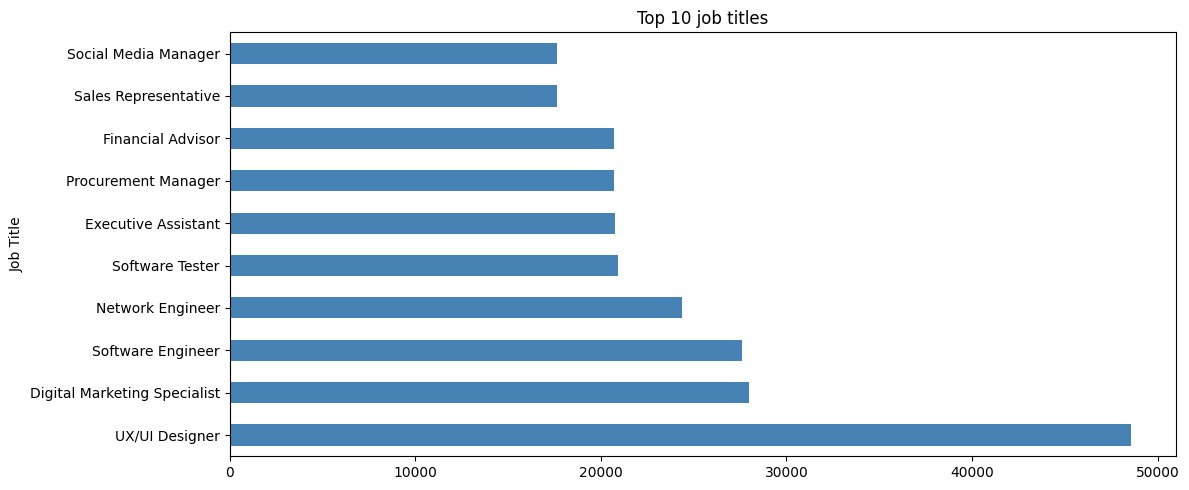

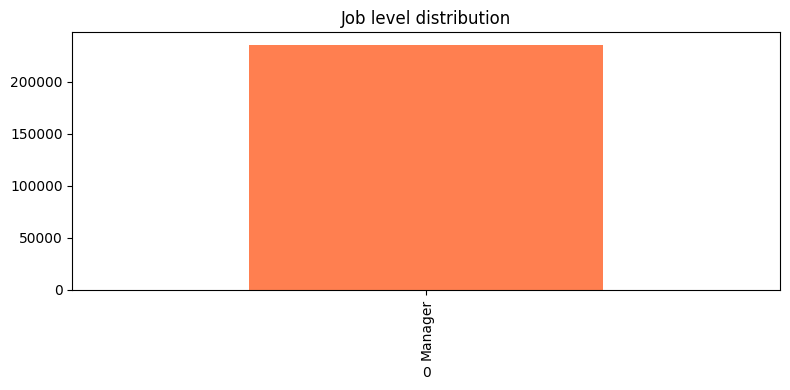

In [6]:
# Top 10 Job Titles
plt.figure(figsize=(12,5))
df['Job Title'].value_counts().head(10).plot(kind='barh', color='steelblue')
plt.title('Top 10 job titles')
plt.tight_layout()
plt.show()

# Job Level Distribution
plt.figure(figsize=(8,4))
df['Job Title'].str.extract('(Senior|Junior|Lead|Manager|Intern)')[0]\
.value_counts().plot(kind='bar', color='coral')
plt.title('Job level distribution')
plt.tight_layout()
plt.show()

In [7]:
# Check format in skills column 
print(type(df['skills'][0]))
print(df['skills'][0])

<class 'str'>
Social media platforms (e.g., Facebook, Twitter, Instagram) Content creation and scheduling Social media analytics and insights Community engagement Paid social advertising


In [8]:
import ast

def parse_skills(skill_val):
    if pd.isna(skill_val):
        return []
    try:
        
        return ast.literal_eval(skill_val)
    except:
        
        return [s.strip() for s in str(skill_val).split(',')]

df['skills_list'] = df['skills'].apply(parse_skills)


print(df['skills_list'].head(5))

0    [Social media platforms (e.g., Facebook, Twitt...
1    [HTML, CSS, JavaScript Frontend frameworks (e....
2    [Quality control processes and methodologies S...
3    [Wireless network design and architecture Wi-F...
4    [Event planning Conference logistics Budget ma...
Name: skills_list, dtype: object


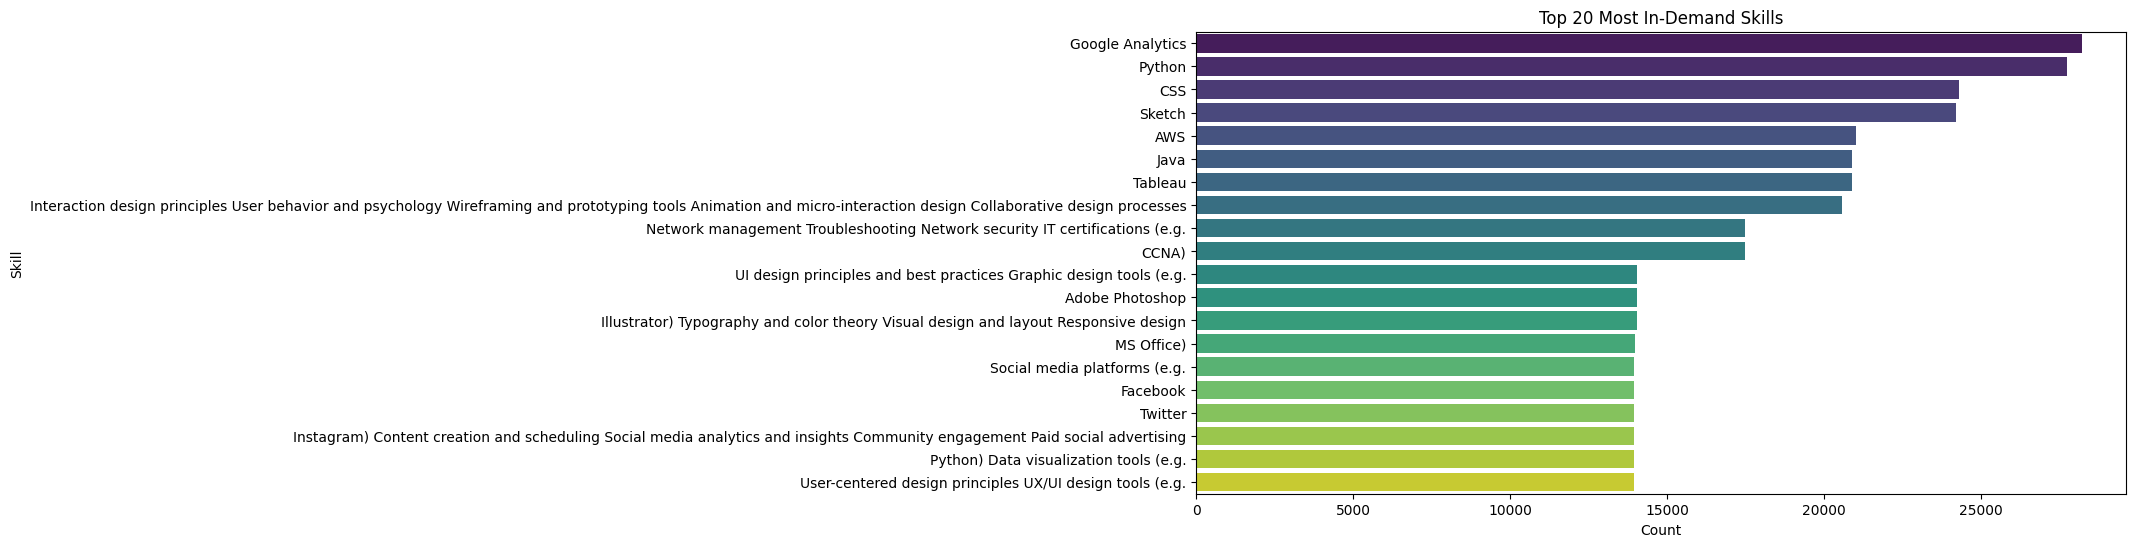

In [9]:
# all skills in  one list 
all_skills = [skill for sublist in df['skills_list'] for skill in sublist]

# Top 20 skills
top_skills = Counter(all_skills).most_common(20)
skills_df = pd.DataFrame(top_skills, columns=['Skill', 'Count'])

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=skills_df, x='Count', y='Skill', palette='viridis')
plt.title('Top 20 Most In-Demand Skills')
plt.tight_layout()
plt.show()

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

# convert skills list to string
df['skills_str'] = df['skills_list'].apply(lambda x: ' '.join(x))

# Job Title clean karo
df['job_title_clean'] = df['Job Title'].str.lower().str.strip()

print(df[['job_title_clean', 'skills_str']].head(3))

                job_title_clean  \
0  digital marketing specialist   
1                 web developer   
2            operations manager   

                                          skills_str  
0  Social media platforms (e.g. Facebook Twitter ...  
1  HTML CSS JavaScript Frontend frameworks (e.g. ...  
2  Quality control processes and methodologies St...  


In [11]:
# TF-IDF — covert every skills to vectore
tfidf = TfidfVectorizer(max_features=100)
skills_matrix = tfidf.fit_transform(df['skills_str'])

print(" Skills matrix shape:", skills_matrix.shape)
print(" Sample features:", tfidf.get_feature_names_out()[:10])

 Skills matrix shape: (1615940, 100)
 Sample features: ['administration' 'adobe' 'analysis' 'analytics' 'and' 'assessment'
 'attention' 'automation' 'building' 'business']


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# Target — predict job Title from skills 
le = LabelEncoder()
df['job_label'] = le.fit_transform(df['job_title_clean'])

# Train/Test Split
X = skills_matrix
y = df['job_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model Train
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_, labels=np.unique(y_pred)))

                                     precision    recall  f1-score   support

                   account director       1.00      1.00      1.00      1443
                  account executive       1.00      1.00      1.00      2090
                    account manager       1.00      1.00      1.00      2730
                         accountant       1.00      1.00      1.00      2169
           administrative assistant       1.00      1.00      1.00      3493
                 aerospace engineer       1.00      1.00      1.00      2105
                          architect       1.00      1.00      1.00      2794
             architectural designer       1.00      1.00      1.00      1359
                       art director       1.00      1.00      1.00      2038
                        art teacher       1.00      1.00      1.00      2100
                 back-end developer       1.00      1.00      1.00      1393
                   brand ambassador       1.00      1.00      1.00      212

In [13]:
#  check how many unique job titles
print("Unique Jobs:", df['job_title_clean'].nunique())

Unique Jobs: 147


In [14]:
import joblib

joblib.dump(model, 'model.pkl')
joblib.dump(tfidf, 'tfidf.pkl')
joblib.dump(le, 'label_encoder.pkl')

print(" Model saved successfully!")

 Model saved successfully!


In [15]:
def analyze_gap(resume_skills, job_title):
    #  extract the Job data 
    job_data = df[df['job_title_clean'] == job_title.lower()]
    
    if job_data.empty:
        print(" Job not found! Available jobs:")
        print(df['job_title_clean'].value_counts().head(10))
        return
    
    # Also match the skills in the dataset to skills_db
    all_job_text = " ".join([
        str(skills) for skills in job_data['skills_list']
    ]).lower()
    
    #  Required skills — Match the text of the dataset with SKILLS_DB
    required_skills = set([
        skill for skill in SKILLS_DB 
        if skill in all_job_text
    ])
    
    user_skills = set(resume_skills)
    
    #  calculate gap
    matched = user_skills & required_skills
    missing = required_skills - user_skills
    
    match_score = round(len(matched) / len(required_skills) * 100, 2) if required_skills else 0
    
    print(f"\n Job: {job_title}")
    print(f" Match Score: {match_score}%")
    print(f" Skills You Have ({len(matched)}): {matched}")
    print(f" Skills You Need ({len(missing)}): {missing}")
    
    return {
        "score": match_score,
        "matched": list(matched),
        "missing": list(missing)
    }


result = analyze_gap(resume_skills, "data scientist")

NameError: name 'resume_skills' is not defined

In [ ]:

print(df['job_title_clean'].value_counts().head(15))

job_title_clean
ux/ui designer                  48551
digital marketing specialist    27975
software engineer               27630
network engineer                24393
software tester                 20945
executive assistant             20776
procurement manager             20734
financial advisor               20687
sales representative            17664
social media manager            17613
network administrator           17581
administrative assistant        17484
data analyst                    17402
event planner                   17384
procurement specialist          17348
Name: count, dtype: int64


In [ ]:
import os
print(os.getcwd())

C:\Users\ninja
